# **Лабораторная работа №9. "Построение моделей прогноза неуспевающих на курсе"**
---

D-FC-1.1-Б2-1: Использует передовые способы эффективного обучения ML-моделей при заданных условиях для часто встречающихся задач

D-FC-1.1-Б2-2: Выполняет оптимизацию ML-моделей, обоснованно используя передовые способы обучения (AutoML)

## Цель работы:

изучить способы построения и автотюнинга пайплайнов, исследовать различные варианты генерации признаков для улучшения моделей с помощью autoML.

## **Описание кейса**

Для организации учебного процесса стали использоваться в большом количестве онлайн-курсы. Но без контроля и соответствующего сопровождения обучение с применением онлайн-ресурсов может дать очень плачевный результат. Необходимо внедрять элементы контроля и сопровождения обучения студентов на онлайн-курсах.

Одной из таких задач построения интеллектуального тьютора онлайн-оубчения является задача прогноза конечного результата обучения на онлайн-курсе: сможет ли он успешно завершить курс в зависимости от его результатов работы в первой части курса.

Эту задачу можно решать разными способами.
1. Можно попробовать построить зависимость финального балла от результатов выполнения пройденных заданий курса. И в зависимости от предсказания определить - на какую оценку претендует пользователь и сможет ли он успешно завершить курс.
2. Можно решать задачу классификации, попытаться определить - к какому классу следует отнести данного слушателя, к классу успешно завершивших или к противоположному классу? Отнести его к классу тех, кто завершил курс на отлично или на удовлетворительно или не завершил.

В этом кейсе вы должны будете:
- исследовать различные алгоритмы и модели обучения классификатора учащихся по результатам выполнения первых пройденных заданий;
- оценить верхнюю границу точности классификатора на имеющихся данных;
- выбрать pipeline, применить автотюнинг и сравнить полученные результаты с лучшей моделью.

В качестве безлайна будем использовать логистическую регрессию.Вам нужно будет исследовать возможность улучшить данный результат за счет тюнинга пайплайна выбора признаков, выбора модели и параметров.

----------

В предыдуще лабораторной работе мы уже выполнили предподготовку данных:
- проанализировали, предобработали и разметили скачанные с курса данные - журнал оценок;
- отделили результаты первой половины курса и подготовили выборку для обучения и оценки моделей;
- исследовали полезность добавления дополнительных признаков (полиномиальных, логических).

После выбора метрик, построения и исследования моделей необходимо применить autoML и сравнить полученный результат с имеющимися моделями.

## **1. Загрузка и знакомство с исходными данными**
---
В качестве исходных данных мы будем использовать результаты выгрузки журнала оценок с онлайн-курса, который содержит результаты выполнения заданий онлайн-курса слушателями (объектно-признаковая матрица) и их финальные баллы (последний или 1-й столбец).

In [1]:
# импорт необходимых библиотек работы с данными
import numpy as np
np.set_printoptions(precision=3)

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')

### **Чтение данных из файла**
---

Для последующего анализа результатов будет полезно загрузить исходных датасет с названиями видов работ.

In [3]:
# выбор файла данных
course_file_name = "CompMath.csv"
csv_file_path = "https://raw.githubusercontent.com/goncharovnskrm-rgb/MO-fos-repository/refs/heads/main/resources/datasets/CompMath.csv"

# Чтение данных из файла *.csv
data = pd.read_csv(csv_file_path, sep=";")
print(data.shape)
data.tail()

(630, 43)


,Имя,Учреждение (организация),sum,Тест:1.1.5. Знакомство с Python (ТЕСТ) (Значение),Тест:1.2.9. Базовые типы данных в Python (ТЕСТ) (Значение),Тест:1.2.10. Управляющие структуры Python (ТЕСТ) (Значение),Тест:1.3.11. Функции и методы в Python (ТЕСТ) (Значение),"Тест:1.3.12. Кортежи,списки,словари в Python (ТЕСТ) (Значение)",Тест:1.4.11. Работа с массивами NumPy (ТЕСТ) (Значение),Тест:1.4.12. Работа с файлами и построение графиков (ТЕСТ) (Значение),...,Виртуальная лаборатория программирования:2.5.3. Программируем управление мобильным роботом (ВПЛ) (Значение),Пакет SCORM:2.3.4. Метод дихотомии и метод хорд (ВИДЕО) (Значение),Тест:ИТОГОВЫЙ ТЕСТ ПО РАЗДЕЛУ - РЕШЕНИЕ СИСТЕМ УРАВНЕНИЙ (Значение),Тест:3.1.5. Одномерная интерполяция (ТЕСТ) (Значение),Тест:3.2.5. Интерполяция поверхностей (ТЕСТ) (Значение),Тест:3.0.5. Постановки задач аппроксимации функций (ТЕСТ) (Значение),Тест:4.1.7. Линейный регрессионный анализ (ТЕСТ) (Значение),Виртуальная лаборатория программирования:4.1.8 Прогноз итоговой суммы баллов на онлайн-курсе (Значение),Тест:4.2.5. Логистическая регрессия (ТЕСТ) (Значение),"Виртуальная лаборатория программирования:4.2.6 Классификация слушателей онлайн-курса (Значение),,,,,,,,,,,"
625,Владислав,Волгатех,"50,04",2,5,5,5,"4,5","3,38","3,17",...,-,-,-,-,-,-,-,-,-,"-,,,,,,,,,"
626,Илья,Политехнический институт (филиал) СВФУ в г. Ми...,0,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,"-,,,,,,,,,,,,,"
627,МГУ_Саранск_104,ФГБОУ ВО «Национальный исследовательский Мордо...,"85,04","2,58",5,5,5,5,4,"2,17",...,-,-,12,-,-,-,-,-,-,"-,,,,,,,,"
628,Антон,ПГТУ,"35,08","1,13",4,5,5,5,"3,25",-,...,-,-,-,-,-,-,-,-,-,"-,,,,,,,,,"
629,Анастасия,ННГУ Лобачевского,"64,89","2,23","3,5",4,4,5,4,"2,67",...,-,-,-,-,-,-,-,-,-,"-,,,,,,,,"


### **Описание датасета**
---
Данный датасет получен в результате прохождения студентами онлайн-курса "Программирование в Python и методы вычислений" на портале портала открытого образования Волгатеха (https://mooped.net/).
Это результат экспорта журнала оценок и очистки от чувствительной информации.

Полное описание датасета см. в предыдущей лаб.работе.

## **Исследуем и оцениваем различные модели классификаторов**
---

### **Загрузка и формирование массивов входных - выходных данных**
---
А теперь загрузим датасет с которым будем работать в этой лабраторной работе


In [4]:
# **3.1 Загружаем данные из файла**
datafile = csv_file_path = "https://raw.githubusercontent.com/goncharovnskrm-rgb/MO-fos-repository/refs/heads/main/resources/datasets/CompMath_part1_tiny.csv"
data_3 = pd.read_csv(datafile, sep=";")
data_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439 entries, 0 to 438
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   T:1.1.5.     439 non-null    float64
 1   T:1.2.9.     439 non-null    float64
 2   T:1.2.10.    439 non-null    float64
 3   VPL:1.2.11.  439 non-null    float64
 4   VPL:1.2.12.  439 non-null    float64
 5   VPL:1.2.13.  439 non-null    float64
 6   T:1.3.11.    439 non-null    float64
 7   T:1.3.12.    439 non-null    float64
 8   VPL:1.3.13.  439 non-null    float64
 9   VPL:1.3.14.  439 non-null    float64
 10  VPL:1.3.15.  439 non-null    float64
 11  VPL:1.3.16.  439 non-null    float64
 12  T:1.4.11.    439 non-null    float64
 13  T:1.4.12.    439 non-null    float64
 14  VPL:1.4.13.  439 non-null    float64
 15  VPL:1.4.14.  439 non-null    float64
 16  VPL:1.4.15.  439 non-null    float64
 17  sumball      439 non-null    float64
 18  label        439 non-null    int64  
dtypes: float

In [5]:
# Выделяем входные и выходные параметры в отдельные массивы
X = data_3.values[:, 0:-7]
y = data_3['sumball']
labels = data_3['label']

X.shape, y.shape, labels.shape

((439, 12), (439,), (439,))

### **1.1. Строим логистическую регрессию**
---

Используем кросс-валидацию для построения линейной зависимости. Но прежде чем применить кросс-валидацию необходимо разделить выборку на обучающую и тестовую.

In [6]:
import numpy as np
from sklearn.model_selection import train_test_split

# Get the indices of the full dataset
indices = np.arange(len(X))

# Split X, y, and their corresponding indices
x_train, x_test, labels_train, labels_test, train_indices, test_indices = train_test_split(
    X, labels, indices, test_size=0.25, random_state=42
)

print(f"Train indices shape: {train_indices.shape}")
print(f"Test indices shape: {test_indices.shape}")

Train indices shape: (329,)
Test indices shape: (110,)


#### **Построение логистической регрессии без дополнительных предикторов**
--------

Т.е. будем строить простую модель вида:

$$y_m(t) = sigmoid(a_0 + a_1*x_1 + ...+ a_k*x_k)$$


In [7]:
from sklearn.linear_model import LogisticRegression
# здесь Ваш код ...
lr = LogisticRegression()
lr_model = lr.fit(x_train, labels_train)

print('a0=', lr_model.intercept_)
print(lr_model.coef_)

a0= [-10.541]
[[ 0.164  0.496 -0.504  0.133  0.445  0.278  0.542  0.459  0.026  0.224
   0.711  0.705]]


Оценим ее точность на тестовой выборке

In [8]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# точность прогноза тех, кто успешно завершит обучение
labels_predicted = lr_model.predict(x_test)
print("accuracy = {:.4f}".format(accuracy_score(labels_test, labels_predicted)))
print('f1_score=', f1_score(labels_test, labels_predicted))
print('roc_auc_score=', roc_auc_score(labels_test, labels_predicted))

sum(labels_predicted), sum(labels_test)

accuracy = 0.9091
f1_score= 0.8648648648648649
roc_auc_score= 0.88912964969303


(np.int64(35), 39)

## **2. Применяем autoML**
---
Применим автотюнинг параметров генерации и подготовки признаков и параметров модели. Для этого:

- установим и импортируем классы из библиотеки Сбера lightAutoML;
- используем класс TabularAutoML для тюнинга параметров Pipeline (берем по умолчанию).
- проанализируем полученные модели с использованием декоратора ReportDeco.

>> ВНИМАНИЕ!
Для использования библиотеки lightAutoML необходимо выбрать выиртуальную конфигурацию с версией python 3.9 - 3.11. не старше!
При работе в Colab, необходимо зайти в "Runtime" -> "change runtime" и выбрать среду с нужной версией python.

После установки библиотеки lightAutoML в среде Colab потребуется перезапустить сеанс.


In [9]:
!python --version

Python 3.11.13


In [10]:
!pip install -U lightautoml

### **2.1. Применяем autoML**

In [11]:
# Standard python libraries
import os
import time

# Installed libraries
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from sklearn.model_selection import train_test_split
import torch
import matplotlib.pyplot as plt

In [12]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [13]:
# LightAutoML presets, task and report generation
from lightautoml.automl.presets.tabular_presets import TabularAutoML, TabularUtilizedAutoML
from lightautoml.tasks import Task
from lightautoml.report.report_deco import ReportDeco, ReportDecoUtilized
from lightautoml.addons.tabular_interpretation import SSWARM

/usr/local/lib/python3.11/dist-packages/lightautoml/transformers/text.py:23: UserWarning: 'fasttext' - package isn't installed
  warnings.warn("'fasttext' - package isn't installed")


In [14]:
N_THREADS = 4
N_FOLDS = 5
RANDOM_STATE = 42
TEST_SIZE = 0.2
TIMEOUT = 300
TARGET_NAME = 'label'

In [15]:
data_3.columns

Index(['T:1.1.5.', 'T:1.2.9.', 'T:1.2.10.', 'VPL:1.2.11.', 'VPL:1.2.12.',
       'VPL:1.2.13.', 'T:1.3.11.', 'T:1.3.12.', 'VPL:1.3.13.', 'VPL:1.3.14.',
       'VPL:1.3.15.', 'VPL:1.3.16.', 'T:1.4.11.', 'T:1.4.12.', 'VPL:1.4.13.',
       'VPL:1.4.14.', 'VPL:1.4.15.', 'sumball', 'label'],
      dtype='object')

In [16]:
# готовим датасет. ограничимся результатами 3-х первых недель обучения на курсе:
cols = ['T:1.1.5.', 'T:1.2.9.', 'T:1.2.10.', 'VPL:1.2.11.', 'VPL:1.2.12.',
       'VPL:1.2.13.', 'T:1.3.11.', 'T:1.3.12.', 'VPL:1.3.13.', 'VPL:1.3.14.',
       'VPL:1.3.15.', 'VPL:1.3.16.', 'label']

dataDF = data_3.loc[:, cols]
dataDF.head()

,T:1.1.5.,T:1.2.9.,T:1.2.10.,VPL:1.2.11.,VPL:1.2.12.,VPL:1.2.13.,T:1.3.11.,T:1.3.12.,VPL:1.3.13.,VPL:1.3.14.,VPL:1.3.15.,VPL:1.3.16.,label
0,1.00,1.33,5.0,0.0,0.0,0.0,1.0,4.5,0.0,0.0,0.0,0.0,0
1,0.76,0.83,5.0,0.0,0.0,0.0,2.0,4.5,0.0,0.0,0.0,0.0,0
2,2.63,5.00,5.0,5.0,5.0,5.0,5.0,5.0,5.0,2.0,3.0,3.0,1
3,2.18,2.50,5.0,5.0,5.0,5.0,4.0,4.0,5.0,2.0,3.0,3.0,1
4,0.00,0.17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [17]:
dataDF.shape, dataDF.columns

((439, 13),
 Index(['T:1.1.5.', 'T:1.2.9.', 'T:1.2.10.', 'VPL:1.2.11.', 'VPL:1.2.12.',
        'VPL:1.2.13.', 'T:1.3.11.', 'T:1.3.12.', 'VPL:1.3.13.', 'VPL:1.3.14.',
        'VPL:1.3.15.', 'VPL:1.3.16.', 'label'],
       dtype='object'))

In [27]:
# делим выбрку на обучающую и тестовую
train_data, test_data = train_test_split(
    dataDF,
    test_size=TEST_SIZE,
    stratify=dataDF[TARGET_NAME],
    random_state=RANDOM_STATE
)

print(f'Data is splitted. Parts sizes: train_data = {train_data.shape}, test_data = {test_data.shape}')

train_data.head()

Data is splitted. Parts sizes: train_data = (351, 13), test_data = (88, 13)


,T:1.1.5.,T:1.2.9.,T:1.2.10.,VPL:1.2.11.,VPL:1.2.12.,VPL:1.2.13.,T:1.3.11.,T:1.3.12.,VPL:1.3.13.,VPL:1.3.14.,VPL:1.3.15.,VPL:1.3.16.,label
122,1.91,4.00,5.0,5.0,5.0,0.0,5.0,4.5,0.0,0.0,0.0,0.0,1
38,1.29,0.83,0.5,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0
105,2.78,5.00,5.0,5.0,5.0,5.0,5.0,5.0,5.0,2.0,3.0,3.0,1
19,1.70,0.00,5.0,5.0,5.0,5.0,5.0,4.5,0.0,0.0,0.0,0.0,0
258,2.70,4.50,5.0,5.0,5.0,5.0,5.0,4.5,5.0,2.0,3.0,3.0,1


In [19]:
task = Task('binary')

roles = {
    'target': TARGET_NAME,
    # 'drop': ['SK_ID_CURR']
}

In [20]:
automl = TabularAutoML(
    task = task,
    timeout = TIMEOUT,
    cpu_limit = N_THREADS,
    reader_params = {'n_jobs': N_THREADS, 'cv': N_FOLDS, 'random_state': RANDOM_STATE},
)

In [21]:
%%time
out_of_fold_predictions = automl.fit_predict(train_data, roles = roles, verbose = 1)

[13:17:39] Stdout logging level is INFO.


INFO:lightautoml.automl.presets.base:Stdout logging level is INFO.


[13:17:39] Copying TaskTimer may affect the parent PipelineTimer, so copy will create new unlimited TaskTimer


[13:17:39] Task: binary



INFO:lightautoml.automl.presets.base:Task: binary



...

[13:21:00] Automl preset training completed in 200.55 seconds



INFO:lightautoml.automl.presets.base:Automl preset training completed in 200.55 seconds



[13:21:00] Model description:
Final prediction for new objects (level 0) = 
	 0.12811 * (5 averaged models Lvl_0_Pipe_0_Mod_0_LinearL2) +
	 0.58009 * (5 averaged models Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM) +
	 0.29180 * (5 averaged models Lvl_0_Pipe_1_Mod_2_CatBoost) 



INFO:lightautoml.automl.presets.base:Model description:
Final prediction for new objects (level 0) = 
	 0.12811 * (5 averaged models Lvl_0_Pipe_0_Mod_0_LinearL2) +
	 0.58009 * (5 averaged models Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM) +
	 0.29180 * (5 averaged models Lvl_0_Pipe_1_Mod_2_CatBoost) 



CPU times: user 2min 37s, sys: 39.7 s, total: 3min 17s
Wall time: 3min 20s


In [44]:
%%time

test_predictions = automl.predict(test_data)
print(f'Prediction for test_data:\n{test_predictions}\nShape = {test_predictions.shape}')

Prediction for test_data:
array([[0.877],
       [0.076],
       [0.087],
       [0.878],
       [0.084],
       [0.076],
       [0.878],
       [0.86 ],
       [0.878],
       [0.405],
       [0.858],
       [0.27 ],
       [0.876],
       [0.451],
       [0.256],
       [0.413],
       [0.079],
       [0.856],
       [0.092],
       [0.538],
       [0.277],
       [0.594],
       [0.522],
       [0.577],
       [0.513],
       [0.101],
       [0.799],
       [0.091],
       [0.211],
       [0.286],
       [0.246],
       [0.384],
       [0.401],
       [0.877],
       [0.841],
       [0.513],
       [0.079],
       [0.076],
       [0.876],
       [0.878],
       [0.169],
       [0.076],
       [0.077],
       [0.604],
       [0.076],
       [0.857],
       [0.106],
       [0.708],
       [0.099],
       [0.878],
       [0.076],
       [0.871],
       [0.286],
       [0.076],
       [0.36 ],
       [0.084],
       [0.403],
       [0.082],
       [0.085],
       [0.847],
       [0.077]

In [37]:
print(f'OOF score: {roc_auc_score(train_data[TARGET_NAME].values, out_of_fold_predictions.data[:, 0])}')
print(f'test roc_auc score: {roc_auc_score(test_data[TARGET_NAME].values, test_predictions.data[:, 0])}')
print(f'test accuracy score: {accuracy_score(test_data[TARGET_NAME].values, np.round(test_predictions.data[:, 0], 0).astype(int))}')

OOF score: 0.9691861245303275
test roc_auc score: 0.9797008547008546
test accuracy score: 0.9204545454545454


### **2.2. Анализ модели**
---

In [45]:
# экспресс - анализ pipeline
print(automl.create_model_str_desc())

Final prediction for new objects (level 0) = 
	 0.12811 * (5 averaged models Lvl_0_Pipe_0_Mod_0_LinearL2) +
	 0.58009 * (5 averaged models Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM) +
	 0.29180 * (5 averaged models Lvl_0_Pipe_1_Mod_2_CatBoost) 


In [47]:
# более детальный анализ использует ReportDeco
%%time

RD = ReportDeco(output_path = 'tabularAutoML_model_report')

automl_rd = RD(
    TabularAutoML(
        task = task,
        timeout = TIMEOUT,
        cpu_limit = N_THREADS,
        reader_params = {'n_jobs': N_THREADS, 'cv': N_FOLDS, 'random_state': RANDOM_STATE}
    )
)

out_of_fold_predictions = automl_rd.fit_predict(train_data, roles = roles, verbose = 1)

[14:03:21] Stdout logging level is INFO.


INFO:lightautoml.automl.presets.base:Stdout logging level is INFO.


[14:03:21] Task: binary



INFO:lightautoml.automl.presets.base:Task: binary



[14:03:21] Start automl preset with listed constraints:


...

[14:06:46] Automl preset training completed in 205.32 seconds



INFO:lightautoml.automl.presets.base:Automl preset training completed in 205.32 seconds



[14:06:46] Model description:
Final prediction for new objects (level 0) = 
	 0.12811 * (5 averaged models Lvl_0_Pipe_0_Mod_0_LinearL2) +
	 0.58009 * (5 averaged models Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM) +
	 0.29180 * (5 averaged models Lvl_0_Pipe_1_Mod_2_CatBoost) 



INFO:lightautoml.automl.presets.base:Model description:
Final prediction for new objects (level 0) = 
	 0.12811 * (5 averaged models Lvl_0_Pipe_0_Mod_0_LinearL2) +
	 0.58009 * (5 averaged models Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM) +
	 0.29180 * (5 averaged models Lvl_0_Pipe_1_Mod_2_CatBoost) 



CPU times: user 2min 49s, sys: 41.6 s, total: 3min 30s
Wall time: 3min 27s


In [48]:
%%time

test_predictions = automl_rd.predict(test_data)
print(f'Prediction for test_data:\n{test_predictions}\nShape = {test_predictions.shape}')

Prediction for test_data:
array([[0.877],
       [0.076],
       [0.087],
       [0.878],
       [0.084],
       [0.076],
       [0.878],
       [0.86 ],
       [0.878],
       [0.405],
       [0.858],
       [0.27 ],
       [0.876],
       [0.451],
       [0.256],
       [0.413],
       [0.079],
       [0.856],
       [0.092],
       [0.538],
       [0.277],
       [0.594],
       [0.522],
       [0.577],
       [0.513],
       [0.101],
       [0.799],
       [0.091],
       [0.211],
       [0.286],
       [0.246],
       [0.384],
       [0.401],
       [0.877],
       [0.841],
       [0.513],
       [0.079],
       [0.076],
       [0.876],
       [0.878],
       [0.169],
       [0.076],
       [0.077],
       [0.604],
       [0.076],
       [0.857],
       [0.106],
       [0.708],
       [0.099],
       [0.878],
       [0.076],
       [0.871],
       [0.286],
       [0.076],
       [0.36 ],
       [0.084],
       [0.403],
       [0.082],
       [0.085],
       [0.847],
       [0.077]

In [49]:
print(f'OOF score: {roc_auc_score(train_data[TARGET_NAME].values, out_of_fold_predictions.data[:, 0])}')
print(f'test roc_auc score: {roc_auc_score(test_data[TARGET_NAME].values, test_predictions.data[:, 0])}')
print(f'test accuracy score: {accuracy_score(test_data[TARGET_NAME].values, np.round(test_predictions.data[:, 0], 0).astype(int))}')

OOF score: 0.9691861245303275
test roc_auc score: 0.9797008547008546
test accuracy score: 0.9204545454545454


### Анализ важности признаков

CPU times: user 83.3 ms, sys: 3.92 ms, total: 87.2 ms
Wall time: 116 ms


<Axes: xlabel='Feature'>

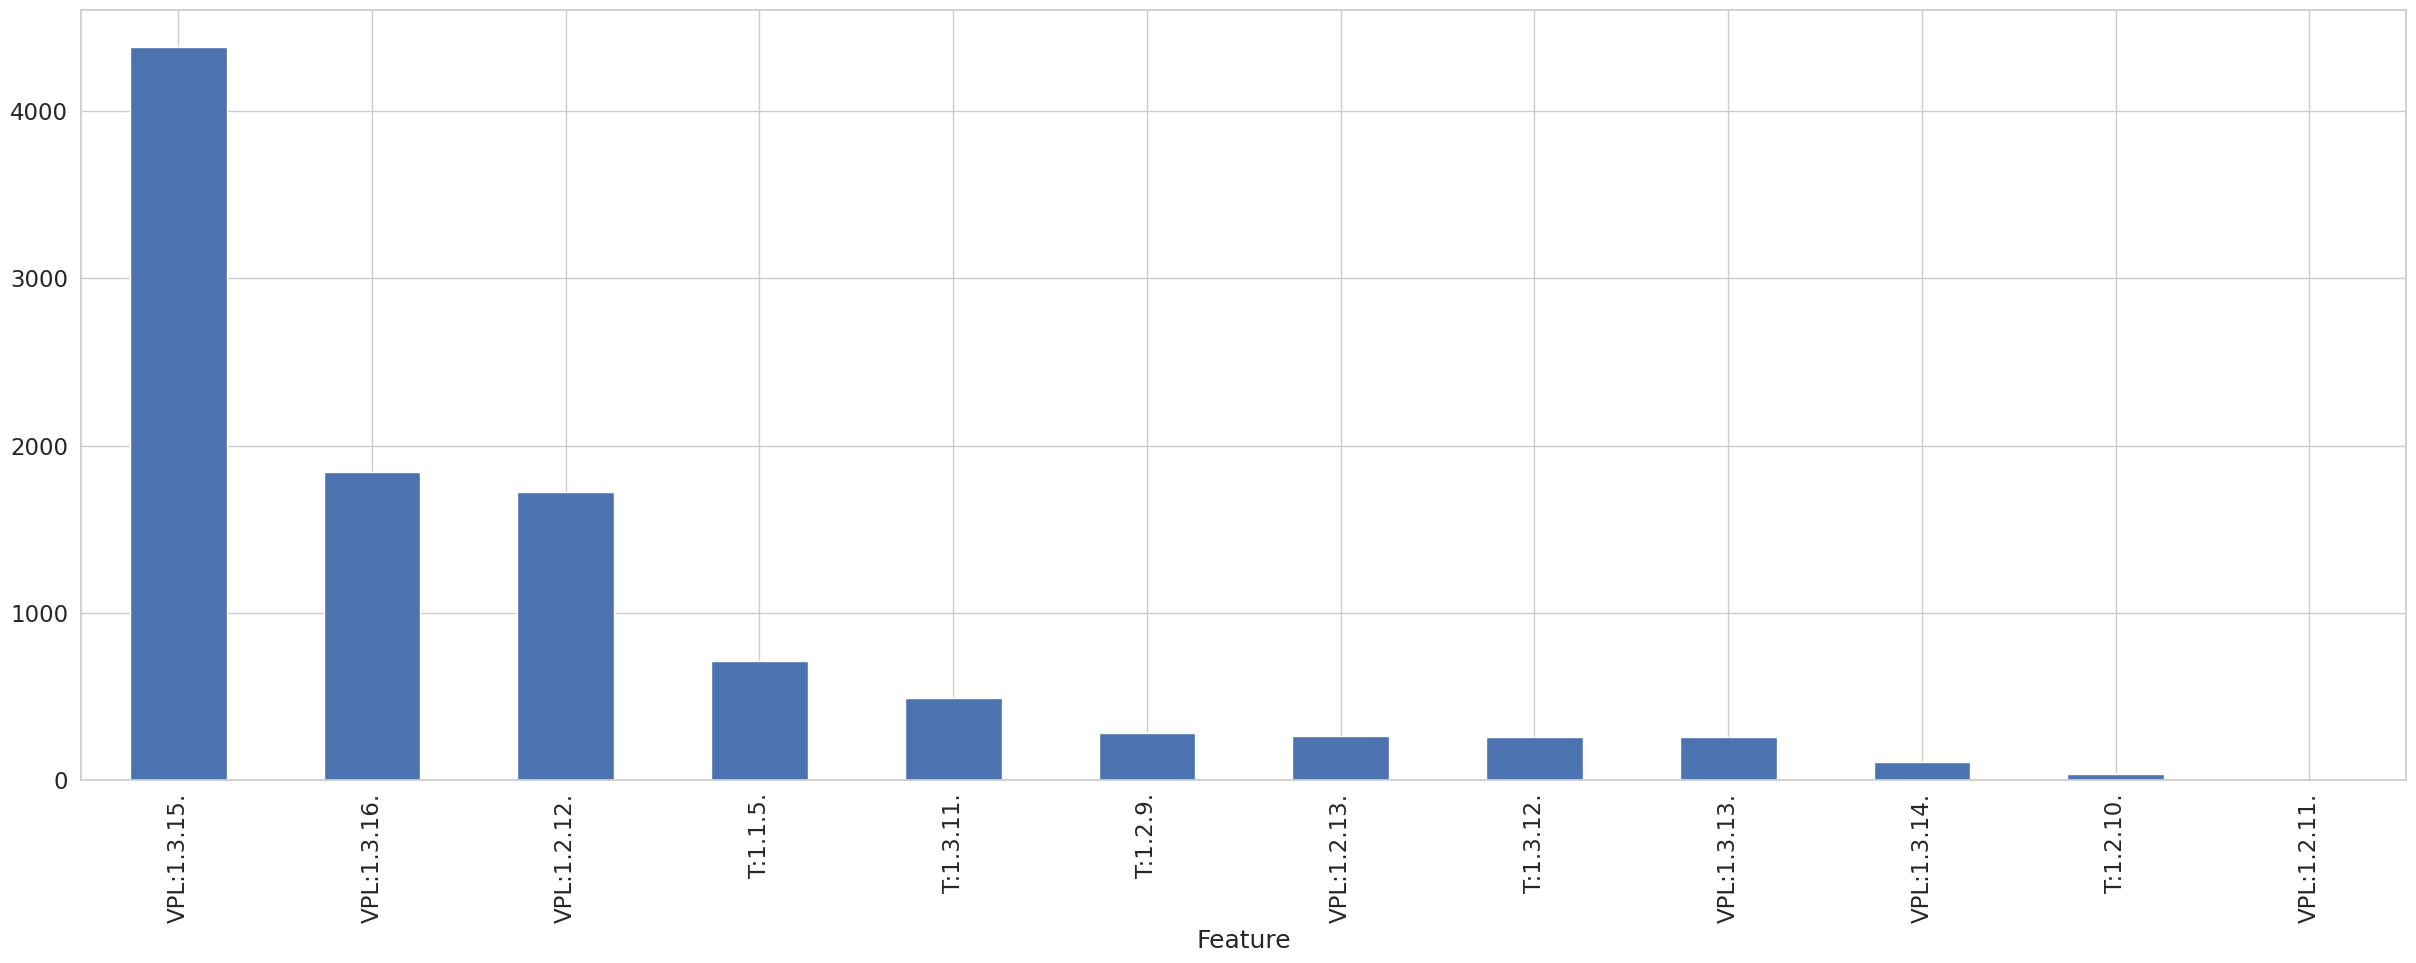

In [50]:
%%time

# Fast feature importances calculation
fast_fi = automl_rd.model.get_feature_scores('fast')
fast_fi.set_index('Feature')['Importance'].plot.bar(figsize = (30, 10), grid = True)

Выводы:

In [54]:
list(data.columns)[3:17]

['Тест:1.1.5. Знакомство с Python (ТЕСТ) (Значение)',
 'Тест:1.2.9. Базовые типы данных в Python (ТЕСТ) (Значение)',
 'Тест:1.2.10. Управляющие структуры Python (ТЕСТ) (Значение)',
 'Тест:1.3.11. Функции и методы в Python (ТЕСТ) (Значение)',
 'Тест:1.3.12. Кортежи,списки,словари в Python (ТЕСТ) (Значение)',
 'Тест:1.4.11. Работа с массивами NumPy (ТЕСТ) (Значение)',
 'Тест:1.4.12. Работа с файлами и построение графиков (ТЕСТ) (Значение)',
 'Виртуальная лаборатория программирования:1.2.11. Встроенные операции с числами (Значение)',
 'Виртуальная лаборатория программирования:1.2.12. Встроенные операции со строками (Значение)',
 'Виртуальная лаборатория программирования:1.2.13. Управляющие структуры в Python. (Значение)',
 'Виртуальная лаборатория программирования:1.3.13. Работа со списками (Значение)',
 'Виртуальная лаборатория программирования:1.3.14. Сортировка слиянием. (Значение)',
 'Виртуальная лаборатория программирования:1.3.15. Расстановка кораблей для морского боя (Значение)',
 

Задание на программирование 1.3.15 самое сложное - надо закодировать расстановку кораблей для мосркого боя согласно правилам. Он требовало (до появления БЯМ) хорошего понимания структур данных и  алгоритмизации. Выполнивший это задание на 90% был готов в плане дальнейшего использования python при решении вычислительных задач. Возможно, что это объясняет его важность и вклад в успешность обучения на курсе. Задание могли выполнить хоршо самые мотивированные и подготовленные.

## **ЗАДАНИЕ**
---
Примените autoML и попробуйте улучшить полученный резльтат: повысить accuracy, roc_auc_score или f1_score (обоснуйте ваш выбор).

Чтобы улучшить модель можно увеличить набор входных признаков, чтобы autoML смог отобрать наиоблее информативные:

- добавить полиномиальные предикторы;
- добавить бинарные признаки (см. лаб.раб.8);
- поиграться с параметрами автотюнинга - исследовать как timeout влияет на полученный результат.

Проанализируйте полученный результат. Исследуйте какие признаки отобрал autoML.

Объясните получившийся результат. Сделайте выводы

#### добавляем полиномиальные признаки

In [24]:
# здесь ваш код

#### добавляем бинарные признаки

In [25]:
# здесь ваш код

применяем autoML (TabularAutoML).

In [ ]:
# здесь ваш код

## **ЗАКЛЮЧЕНИЕ**
---

сделайте выводы по проведенному исследованию ...